# Analysis of the risk of failure of the O-rings on the Challenger shuttle

On January 27, 1986, the day before the takeoff of the shuttle _Challenger_, had
a three-hour teleconference was held between 
Morton Thiokol (the manufacturer of one of the engines) and NASA. The
discussion focused on the consequences of the
temperature at take-off of 31°F (just below
0°C) for the success of the flight and in particular on the performance of the
O-rings used in the engines. Indeed, no test
had been performed at this temperature.

The following study takes up some of the analyses carried out that
night with the objective of assessing the potential influence of
the temperature and pressure to which the O-rings are subjected
on their probability of malfunction. Our starting point is 
the results of the experiments carried out by NASA engineers
during the six years preceding the launch of the shuttle
Challenger.

## Loading the data
We start by loading this data:

In [1]:
import numpy as np
import pandas as pd
data = pd.read_csv("shuttle.csv")
data

,Date,Count,Temperature,Pressure,Malfunction
0,4/12/81,6,66,50,0
1,11/12/81,6,70,50,1
2,3/22/82,6,69,50,0
3,11/11/82,6,68,50,0
4,4/04/83,6,67,50,0
5,6/18/82,6,72,50,0
6,8/30/83,6,73,100,0
7,11/28/83,6,70,100,0
8,2/03/84,6,57,200,1
9,4/06/84,6,63,200,1


The data set shows us the date of each test, the number of O-rings (there are 6 on the main launcher), the temperature (in Fahrenheit) and pressure (in psi), and finally the number of identified malfunctions.

## Graphical inspection


In [2]:
# CORRECTION: keep all flights
data

,Date,Count,Temperature,Pressure,Malfunction
0,4/12/81,6,66,50,0
1,11/12/81,6,70,50,1
2,3/22/82,6,69,50,0
3,11/11/82,6,68,50,0
4,4/04/83,6,67,50,0
5,6/18/82,6,72,50,0
6,8/30/83,6,73,100,0
7,11/28/83,6,70,100,0
8,2/03/84,6,57,200,1
9,4/06/84,6,63,200,1


We have a high temperature variability but
the pressure is almost always 200, which should
simplify the analysis.

How does the frequency of failure vary with temperature?

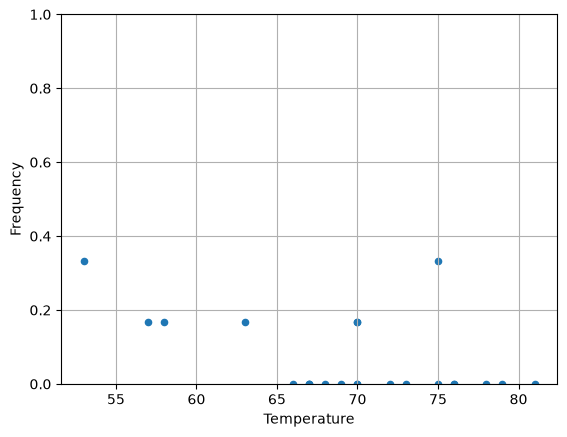

In [3]:
%matplotlib inline
pd.set_option('mode.chained_assignment',None) # this removes a useless warning from pandas
import matplotlib.pyplot as plt

data["Frequency"]=data.Malfunction/data.Count
data.plot(x="Temperature",y="Frequency",kind="scatter",ylim=[0,1])
plt.grid(True)

Flight below 65°F had at least one failure, while above 66°F most of the flights had none.

## Estimation of the temperature influence

Suppose that each of the six O-rings is damaged with the same
probability and independently of the others and that this probability
depends only on the temperature. If $p(t)$ is this probability, the
number $D$ of malfunctioning O-rings during a flight at
temperature $t$ follows a binomial law with parameters $n=6$ and
$p=p(t)$. To link $p(t)$ to $t$, we will therefore perform a
logistic regression.

In [4]:
import statsmodels.api as sm

data["Success"]=data.Count-data.Malfunction
data["Intercept"]=1

# CORRECTION: response = (failures, successes)
logmodel=sm.GLM(data[['Malfunction','Success']], data[['Intercept','Temperature']], family=sm.families.Binomial()).fit()

logmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Generalized Linear Model Regression Results                      
======================================================================================
Dep. Variable:     ['Malfunction', 'Success']   No. Observations:                   23
Model:                                    GLM   Df Residuals:                       21
Model Family:                        Binomial   Df Model:                            1
Link Function:                          Logit   Scale:                          1.0000
Method:                                  IRLS   Log-Likelihood:                -15.823
Date:                        Thu, 08 Oct 2026   Deviance:                       18.086
Time:                                08:42:31   Pearson chi2:                     30.0
No. Iterations:                             6   Pseudo R-squ. (CS):             0.2344
Covariance Type:                    nonrobust                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.0850      3.052      1.666      0.096      -0.898      11.068
Temperature    -0.1156      0.047     -2.458      0.014      -0.208      -0.023
===============================================================================
"""

The temperature coefficient is about -0.116. The 95% confidence interval is about [-0.21, -0.02], and it is all below 0. So the lower the temperature, the higher the probability of O-ring failure.

## Estimation of the probability of O-ring malfunction

The expected temperature on the take-off day is 31°F. Let's try to
estimate the probability of O-ring malfunction at
this temperature from the model we just built:

The observed temperatures only go from 53°F to 81°F, so 31°F is outside the range of the data.

       mean   mean_se  mean_ci_lower  mean_ci_upper
2  0.817774  0.240453       0.159601       0.990658


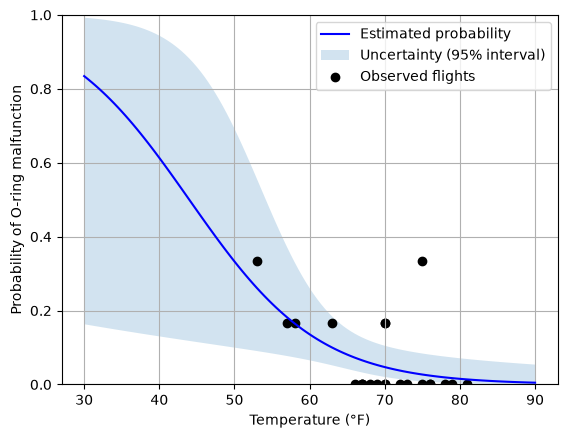

In [5]:
%matplotlib inline
T = np.linspace(30, 90, 121)
data_pred = pd.DataFrame({'Temperature': T, 'Intercept': 1})
pred = logmodel.get_prediction(data_pred[['Intercept','Temperature']]).summary_frame()

plt.plot(T, pred['mean'], color='blue', label='Estimated probability')
plt.fill_between(T, pred['mean_ci_lower'], pred['mean_ci_upper'], alpha=0.2, label='Uncertainty (95% interval)')
plt.scatter(data["Temperature"], data["Frequency"], color='black', label='Observed flights')
plt.xlabel('Temperature (°F)')
plt.ylabel('Probability of O-ring malfunction')
plt.ylim(0,1)
plt.grid(True)
plt.legend(loc='upper right')

print(pred.iloc[[2]])   # the row for 31°F

At 31°F the estimated probability of malfunction is about 0.82 per O-ring, but the 95% interval is very wide (about 0.16 to 0.99), because 31°F is far outside the observed temperatures. The data do not support "temperature has no impact".

In [6]:
# probabilities at 31°F (row 2 of the prediction table above)
p      = pred.loc[2, 'mean']
p_low  = pred.loc[2, 'mean_ci_lower']

# probability that both O-rings of a joint fail, for any of the 3 joints
print("estimate:   ", 1-(1-p**2)**3)
print("lower bound:", 1-(1-p_low**2)**3)

estimate:    0.9636547153205924
lower bound: 0.07448780606078265


The first analysis did not use temperature to compute the final risk, so it got only 1.2%. When we use 31°F, the risk is at least 7%. The launch was not safe.
